# K-Means Team Style Clustering
Groups NBA teams into style archetypes using PCA-reduced features.

In [1]:
import os
import sys
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
with open('data/pca_model.pkl', 'rb') as f:
    pca_data = pickle.load(f)

scaler      = pca_data['scaler']
pca         = pca_data['pca']
FEATURE_COLS = pca_data['feature_cols']
N_COMPONENTS = pca_data['n_components']
X_pca       = pca_data['X_pca']
teams       = pca_data['teams']

# Also load raw features for profile interpretation
df_raw = pd.read_csv('data/team_features.csv').set_index('abbrev')

print(f"Loaded {len(teams)} teams, {N_COMPONENTS} PCA components")

Loaded 30 teams, 5 PCA components


## Choosing K

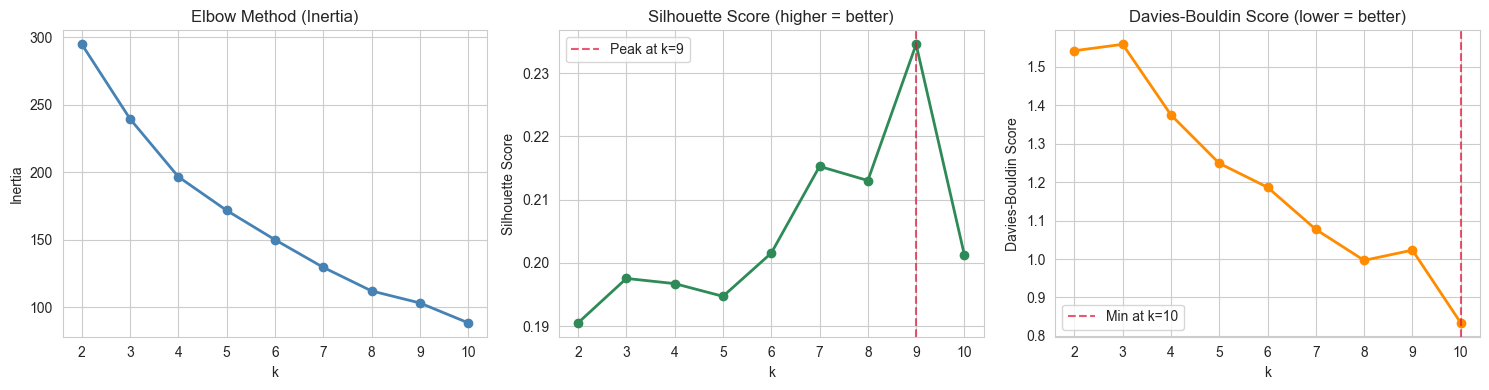

In [3]:
ks = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))

best_k_sil = list(ks)[silhouettes.index(max(silhouettes))]
best_k_db  = list(ks)[db_scores.index(min(db_scores))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Inertia / Elbow
ax = axes[0]
ax.plot(list(ks), inertias, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method (Inertia)')
ax.set_xticks(list(ks))

# Silhouette
ax = axes[1]
ax.plot(list(ks), silhouettes, marker='o', color='seagreen', linewidth=2)
ax.axvline(best_k_sil, linestyle='--', color='crimson', alpha=0.7,
           label=f'Peak at k={best_k_sil}')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score (higher = better)')
ax.set_xticks(list(ks))
ax.legend()

# Davies-Bouldin
ax = axes[2]
ax.plot(list(ks), db_scores, marker='o', color='darkorange', linewidth=2)
ax.axvline(best_k_db, linestyle='--', color='crimson', alpha=0.7,
           label=f'Min at k={best_k_db}')
ax.set_xlabel('k')
ax.set_ylabel('Davies-Bouldin Score')
ax.set_title('Davies-Bouldin Score (lower = better)')
ax.set_xticks(list(ks))
ax.legend()

plt.tight_layout()
plt.savefig('data/kmeans_selection.png', dpi=100)
plt.show()

In [4]:
print(f"{'k':>3} | {'Inertia':>8} | {'Silhouette':>10} | {'Davies-Bouldin':>14}")
print("-" * 44)
for k, i, s, d in zip(ks, inertias, silhouettes, db_scores):
    print(f"{k:>3} | {i:>8.2f} | {s:>10.3f} | {d:>14.3f}")

best_k_sil = list(ks)[silhouettes.index(max(silhouettes))]
print(f"\nBest k by silhouette: {best_k_sil}")
print(f"Best k by Davies-Bouldin: {best_k_db}")

  k |  Inertia | Silhouette | Davies-Bouldin
--------------------------------------------
  2 |   294.85 |      0.191 |          1.542
  3 |   239.52 |      0.198 |          1.559
  4 |   196.65 |      0.197 |          1.375
  5 |   171.73 |      0.195 |          1.249
  6 |   150.04 |      0.202 |          1.187
  7 |   129.57 |      0.215 |          1.077
  8 |   112.09 |      0.213 |          0.997
  9 |   103.20 |      0.235 |          1.023
 10 |    88.48 |      0.201 |          0.834

Best k by silhouette: 9
Best k by Davies-Bouldin: 10


In [5]:
# Set final k — default to 5, adjust based on metrics above
K_FINAL = 5  # David can change this
print(f"Using K_FINAL = {K_FINAL}")

Using K_FINAL = 5


## Fitting Final Model

In [6]:
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca)
final_silhouette = silhouette_score(X_pca, cluster_labels)
print(f"Final silhouette score: {final_silhouette:.3f}")

# Add cluster assignments to teams
df_clusters = pd.DataFrame({'team': teams, 'cluster': cluster_labels})
df_clusters = df_clusters.sort_values(['cluster', 'team']).reset_index(drop=True)

for c in range(K_FINAL):
    teams_in_cluster = df_clusters[df_clusters['cluster'] == c]['team'].tolist()
    print(f"\nCluster {c}: {teams_in_cluster}")

Final silhouette score: 0.195

Cluster 0: ['BKN', 'CHI', 'IND', 'MIL', 'UTA', 'WAS']

Cluster 1: ['DET', 'GSW', 'PHX', 'POR']

Cluster 2: ['BOS', 'CHA', 'HOU', 'NYK']

Cluster 3: ['ATL', 'DAL', 'MEM', 'NOP', 'ORL', 'PHI', 'SAC', 'TOR']

Cluster 4: ['CLE', 'DEN', 'LAC', 'LAL', 'MIA', 'MIN', 'OKC', 'SAS']


## Cluster Visualization — PC1 vs PC2

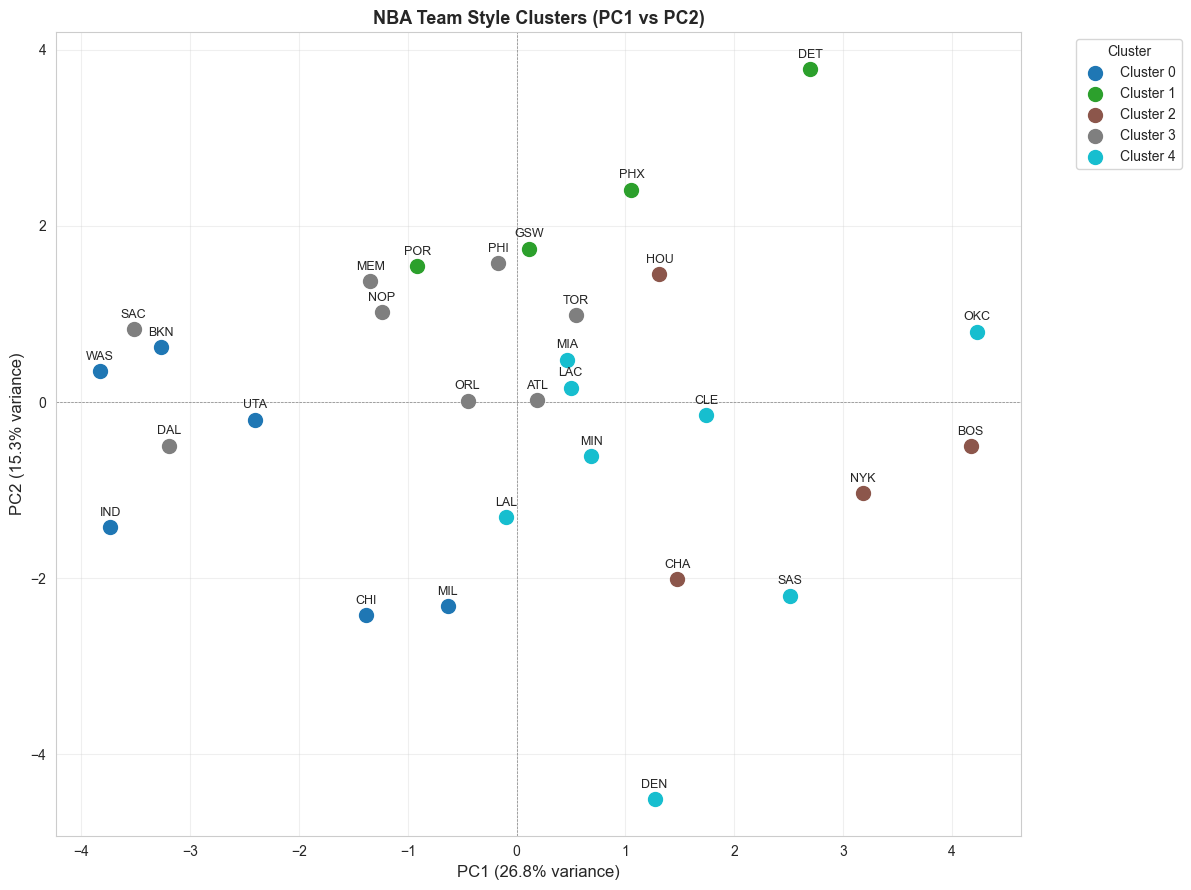

In [7]:
colors = plt.cm.tab10(np.linspace(0, 1, K_FINAL))

fig, ax = plt.subplots(figsize=(12, 9))
for c in range(K_FINAL):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors[c], s=100, label=f'Cluster {c}', zorder=3)
    for i, team in enumerate(teams):
        if cluster_labels[i] == c:
            ax.annotate(team, (X_pca[i, 0], X_pca[i, 1]),
                        fontsize=9, ha='center', va='bottom',
                        xytext=(0, 6), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('NBA Team Style Clusters (PC1 vs PC2)', fontsize=13, fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/cluster_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

## Cluster Profiles

In [8]:
# Get cluster centroids in original feature space
centroids_pca    = kmeans.cluster_centers_                    # shape (K, n_components)
centroids_scaled = pca.inverse_transform(centroids_pca)       # shape (K, 18)
centroids_raw    = scaler.inverse_transform(centroids_scaled) # shape (K, 18)

df_centroids = pd.DataFrame(centroids_raw, columns=FEATURE_COLS)

# League averages
league_avg = df_raw[FEATURE_COLS].mean()

# Print nicely
for c in range(K_FINAL):
    teams_in_c = df_clusters[df_clusters['cluster'] == c]['team'].tolist()
    print(f"\n{'='*62}")
    print(f"Cluster {c}: {teams_in_c}")
    print(f"{'Feature':<30} {'Cluster Avg':>12} {'League Avg':>12} {'Delta':>8}")
    print("-" * 62)
    for feat in FEATURE_COLS:
        val   = df_centroids.loc[c, feat]
        avg   = league_avg[feat]
        delta = val - avg
        print(f"  {feat:<28} {val:>12.3f} {avg:>12.3f} {delta:>+8.3f}")


Cluster 0: ['BKN', 'CHI', 'IND', 'MIL', 'UTA', 'WAS']
Feature                         Cluster Avg   League Avg    Delta
--------------------------------------------------------------
  three_pt_attempt_rate               0.432        0.416   +0.016
  three_pt_pct                        0.360        0.359   +0.000
  two_pt_pct                          0.545        0.551   -0.006
  ft_point_rate                       0.154        0.160   -0.005
  fga_per_possession                  0.868        0.882   -0.013
  turnover_rate                       0.151        0.144   +0.007
  oreb_rate                           0.132        0.142   -0.011
  transition_rate                     0.079        0.086   -0.007
  off_rating                        111.383      114.573   -3.190
  opp_three_pt_attempt_rate           0.411        0.416   -0.005
  opp_two_pt_pct                      0.573        0.550   +0.022
  opp_turnover_rate                   0.135        0.144   -0.009
  opp_oreb_rate         

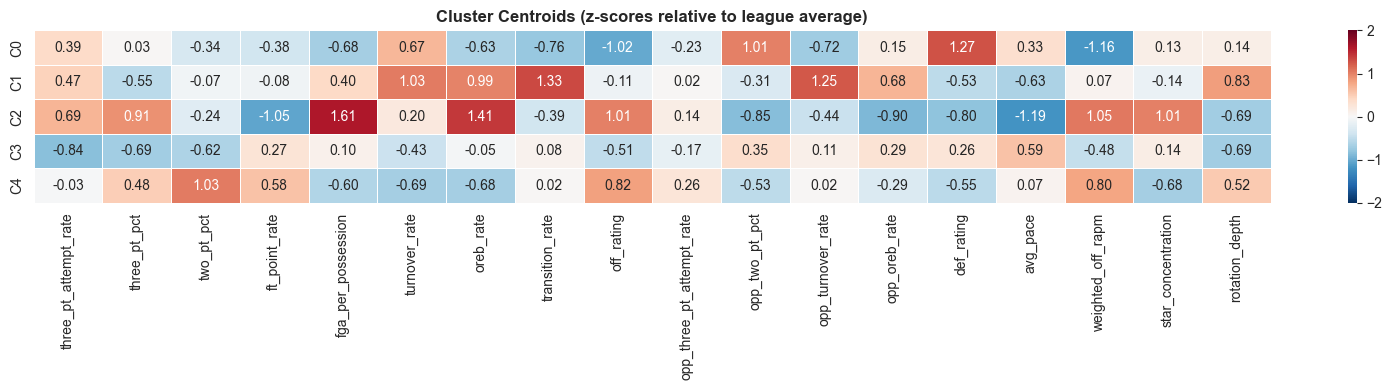

In [9]:
# Normalize centroids relative to std dev (z-scores)
df_centroids_z = (df_centroids - df_raw[FEATURE_COLS].mean()) / df_raw[FEATURE_COLS].std()
df_centroids_z.index = [f'C{c}' for c in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    df_centroids_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=0.5, ax=ax, vmin=-2, vmax=2
)
ax.set_title('Cluster Centroids (z-scores relative to league average)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/cluster_profiles.png', dpi=100, bbox_inches='tight')
plt.show()

## Cluster Naming
Edit the names below based on the cluster profiles above. Look at which features are highest/lowest for each cluster.

In [10]:
# Edit these names based on the cluster profiles above
CLUSTER_NAMES = {
    0: "Cluster 0 — [Name TBD]",
    1: "Cluster 1 — [Name TBD]",
    2: "Cluster 2 — [Name TBD]",
    3: "Cluster 3 — [Name TBD]",
    4: "Cluster 4 — [Name TBD]",
}
# After running, David fills in descriptive names like:
# 0: "3PT Spacing / High Pace"
# 1: "Paint-Heavy / Physical Defense"
# 2: "Balanced / Veteran Teams"
# etc.

print("Cluster assignments:")
for c in range(K_FINAL):
    teams_in_c = df_clusters[df_clusters['cluster'] == c]['team'].tolist()
    print(f"  {CLUSTER_NAMES[c]}: {teams_in_c}")

Cluster assignments:
  Cluster 0 — [Name TBD]: ['BKN', 'CHI', 'IND', 'MIL', 'UTA', 'WAS']
  Cluster 1 — [Name TBD]: ['DET', 'GSW', 'PHX', 'POR']
  Cluster 2 — [Name TBD]: ['BOS', 'CHA', 'HOU', 'NYK']
  Cluster 3 — [Name TBD]: ['ATL', 'DAL', 'MEM', 'NOP', 'ORL', 'PHI', 'SAC', 'TOR']
  Cluster 4 — [Name TBD]: ['CLE', 'DEN', 'LAC', 'LAL', 'MIA', 'MIN', 'OKC', 'SAS']


## Save Outputs

In [11]:
import sys
sys.path.insert(0, '..')

os.makedirs('data', exist_ok=True)
os.makedirs('../downstream', exist_ok=True)

# 1. Build abbrev -> cluster mapping
cluster_assignments = {
    team: int(cluster) for team, cluster in zip(teams, cluster_labels)
}

# team_id -> cluster (via NBA_TEAM_MAP)
from config import NBA_TEAM_MAP
abbrev_to_id = {v['abbrev']: k for k, v in NBA_TEAM_MAP.items()}
cluster_by_team_id = {
    abbrev_to_id[t]: int(c)
    for t, c in cluster_assignments.items()
    if t in abbrev_to_id
}

output_json = {
    'cluster_by_abbrev': cluster_assignments,
    'cluster_by_team_id': cluster_by_team_id,
    'cluster_names': CLUSTER_NAMES,
    'k': K_FINAL,
    'n_components': N_COMPONENTS,
    'silhouette_score': float(final_silhouette),
}
with open('data/cluster_assignments.json', 'w') as f:
    json.dump(output_json, f, indent=2)
print("Saved data/cluster_assignments.json")

# 2. Save production model to downstream/
production_model = {
    'scaler': scaler,
    'pca': pca,
    'kmeans': kmeans,
    'feature_names': FEATURE_COLS,
    'n_components': N_COMPONENTS,
    'k': K_FINAL,
    'cluster_names': CLUSTER_NAMES,
}
with open('../downstream/cluster_model.pkl', 'wb') as f:
    pickle.dump(production_model, f)
print("Saved ../downstream/cluster_model.pkl")

# 3. Save human-readable metadata JSON
meta = {
    'feature_names': FEATURE_COLS,
    'n_components': N_COMPONENTS,
    'k': K_FINAL,
    'cluster_names': CLUSTER_NAMES,
    'silhouette_score': float(final_silhouette),
    'cluster_by_abbrev': cluster_assignments,
    'cluster_by_team_id': cluster_by_team_id,
}
with open('../downstream/cluster_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print("Saved ../downstream/cluster_model_meta.json")

Saved data/cluster_assignments.json
Saved ../downstream/cluster_model.pkl
Saved ../downstream/cluster_model_meta.json
